# 03a · Fraud Analytics Chapter 2 — Data Collection, Sampling and Preprocessing
*Concept-by-concept with explanations and code.* Every concept of the chapter appears below in the book's order. Where the book gives a **worked example with numbers** (WoE table, χ² categorisation, Cramér's V, RIDIT scores…) we **reproduce it in code first** (with an `assert`), then apply the same idea to the lab bank data.

| # | Concept (chapter section) | # | Concept |
|---|---|---|---|
| 1 | Types of data sources | 10 | Red flags |
| 2 | Merging data sources | 11 | Standardizing data |
| 3 | Sampling | 12 | Categorization |
| 4 | Types of data elements | 13 | Weights of evidence coding |
| 5 | Visual data exploration | 14 | Variable selection (filters) |
| 6 | Benford's law | 15 | Principal components analysis |
| 7 | Descriptive statistics | 16 | RIDITs |
| 8 | Missing values | 17 | PRIDIT analysis |
| 9 | Outlier detection and treatment | 18 | Segmentation |

> *Prerequisite:* notebooks 01–02 must have been run once (they create `data/processed/*.pkl`).

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, warnings
warnings.filterwarnings("ignore")
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score
import amlkit as ak

pd.set_option("display.float_format", "{:,.4f}".format); pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid"); rng = np.random.default_rng(0)

txn = pd.read_pickle(ak.PROC / "txn_clean.pkl"); kyc = pd.read_pickle(ak.PROC / "kyc_clean.pkl")
feat = pd.read_pickle(ak.PROC / "features.pkl"); truth = ak.load_truth()
raw = pd.read_csv(ak.RAW / "transactions.csv.gz", parse_dates=["ts"]); kyc_raw = pd.read_csv(ak.RAW / "customers_kyc.csv")
cards = ak.card_features(txn[txn.channel == "card_online"])            # card-not-present table with behavioural features
cards["n_prev_1h_c"] = cards.n_prev_1h.clip(upper=5); cards["n_prev_24h_c"] = cards.n_prev_24h.clip(upper=5)      # counts: cap at 5 -> few discrete levels
y_card = cards.is_fraud.values
print(f"customers {len(feat):,} | card-online txns {len(cards):,} (fraud {cards.is_fraud.mean():.2%}) | customer-level suspicious rate {feat.is_launderer.mean():.2%}")

customers 3,500 | card-online txns 84,463 (fraud 0.45%) | customer-level suspicious rate 3.51%


## 1 · Types of data sources
The chapter distinguishes families of data: **transactional** (OLTP; can be *aggregated* into averages, trends, min/max, and the classic **RFM** — Recency, Frequency, Monetary), **customer / KYC**, **behavioural**, **external**, **unstructured** (e-mail, text) and **network** data. The choice of data drives everything downstream ("garbage in, garbage out").

Below we turn the raw transactional source into an RFM + trend view per customer — the typical first aggregation step.

In [2]:
pay = txn[txn.channel.isin(["card_pos", "card_online"])]
last_day = int(txn.day.max()) + 1
rfm = pay.groupby("customer_id").agg(recency_days=("day", lambda s: last_day - s.max()), frequency=("txn_id", "size"), monetary=("amount_usd", "sum"))
m = pay.assign(period=np.where(pay.day >= last_day - 90, "recent", np.where(pay.day >= last_day - 180, "previous", "older")))
tr = m[m.period != "older"].pivot_table(index="customer_id", columns="period", values="amount_usd", aggfunc="mean")
rfm["trend_mean_amount"] = (tr["recent"] / tr["previous"]).reindex(rfm.index)          # trend: ratio of recent to previous average ticket
rfm = rfm.join(feat.set_index("customer_id").is_launderer)
display(rfm.describe().T[["mean", "50%", "max"]])
print(rfm.groupby("is_launderer")[["recency_days", "frequency", "monetary"]].median())

,mean,50%,max
recency_days,6.4651,4.0000,65.0000
frequency,80.4803,67.0000,461.0000
monetary,"7,660.9353","4,656.9749","113,770.3456"
trend_mean_amount,1.0723,0.9970,7.9365
is_launderer,0.0351,0.0000,1.0000


              recency_days  frequency   monetary
is_launderer                                    
0                   4.0000    67.0000 4,597.4339
1                   3.0000    93.0000 7,114.0134


## 2 · Merging data sources
Analytics wants **one table** (rows = instances/observations, columns = variables/features). Normalised tables are merged on **keys**; the more tables merged, the more duplicate data. Book Figure 2.1 merges *Transactions* with *Customer data* on ID. **Always check the merge** (row count, key coverage, cardinality).

In [3]:
T = pd.DataFrame({"ID": ["XWV", "XWV", "XWV", "BBC", "BBC", "VVQ"], "Date": ["2/01/2015", "6/02/2015", "3/03/2015", "17/02/2015", "1/03/2015", "2/03/2015"], "Amount": [52, 21, 13, 45, 75, 56]})
C = pd.DataFrame({"ID": ["XWV", "BBC", "VVQ"], "Age": [31, 49, 21], "Start date": ["1/01/2015", "10/02/2015", "15/02/2015"]})
merged = T.merge(C, on="ID", how="left", validate="m:1", indicator=True)
assert len(merged) == len(T) and (merged["_merge"] == "both").all()       # no rows lost or multiplied; every key matched
display(merged.drop(columns="_merge"))

# same checks on the lab data
mg = txn.merge(kyc[["customer_id", "segment", "declared_monthly_turnover"]], on="customer_id", how="left", validate="m:1", indicator=True)
print("rows preserved:", len(mg) == len(txn), "| unmatched keys:", int((mg._merge != 'both').sum()))
print("wrongly merged (many-to-many) tables explode row counts, e.g. joining txn to txn on customer_id would give", f"{(txn.groupby('customer_id').size() ** 2).sum():,}", "rows")

,ID,Date,Amount,Age,Start date
0,XWV,2/01/2015,52,31,1/01/2015
1,XWV,6/02/2015,21,31,1/01/2015
2,XWV,3/03/2015,13,31,1/01/2015
3,BBC,17/02/2015,45,49,10/02/2015
4,BBC,1/03/2015,75,49,10/02/2015
5,VVQ,2/03/2015,56,21,15/02/2015


rows preserved: True | unmatched keys: 0
wrongly merged (many-to-many) tables explode row counts, e.g. joining txn to txn on customer_id would give 343,663,287 rows


## 3 · Sampling
Goal: a sample **representative of the future entities** the model will score. Three ideas from the chapter:

1. **Time window trade-off** — more data (robust) vs recent data (representative); avoid *seasonality bias* (e.g. December). Options: separate models per period (costly to operate) or **one sample covering a full business cycle**.
2. **Sampling bias** must be avoided — "which month is representative?"
3. **Stratified sampling** — keep the target ratio (e.g. 99 % / 1 %) in the sample; optionally stratify on key predictors.

In [4]:
mth = cards.assign(month=cards.ts.dt.month).groupby("month").agg(txns=("txn_id", "size"), fraud_rate=("is_fraud", "mean"), mean_amount=("amount_usd", "mean"))
year = cards.is_fraud.mean()
mth["fraud_rate_vs_year"] = mth.fraud_rate / year
print(f"full-year card fraud rate = {year:.3%}; a model built on ONE month sees rates between {mth.fraud_rate.min():.3%} and {mth.fraud_rate.max():.3%}")
mth

full-year card fraud rate = 0.453%; a model built on ONE month sees rates between 0.249% and 0.638%


,txns,fraud_rate,mean_amount,fraud_rate_vs_year
month,,,,
1,7142,0.0038,129.9673,0.8337
2,6426,0.0064,129.0915,1.4071
3,7280,0.0048,130.9816,1.0602
4,6942,0.0029,133.5501,0.6354
5,7062,0.0058,133.5245,1.2803
6,6911,0.0036,131.5698,0.7978
7,7220,0.0025,130.2623,0.5498
8,7221,0.0039,134.9197,0.8551
9,6993,0.0056,129.6413,1.2299


In [5]:
# Stratified vs simple random sampling of 2,000 rows: how stable is the number of frauds in the sample?
n_s, reps = 2000, 300
fr_random, fr_strat = [], []
for i in range(reps):
    s = cards.sample(n_s, random_state=i); fr_random.append(s.is_fraud.sum())
    _, s2 = train_test_split(cards, test_size=n_s, stratify=cards.is_fraud, random_state=i); fr_strat.append(s2.is_fraud.sum())
print(f"expected frauds in a 2,000-row sample: {year * n_s:.1f}")
print(f"simple random : mean {np.mean(fr_random):.1f}, sd {np.std(fr_random):.2f}, min {min(fr_random)}, max {max(fr_random)}")
print(f"stratified    : mean {np.mean(fr_strat):.1f}, sd {np.std(fr_strat):.2f}, min {min(fr_strat)}, max {max(fr_strat)}")

expected frauds in a 2,000-row sample: 9.1
simple random : mean 8.9, sd 3.03, min 2, max 22
stratified    : mean 9.0, sd 0.00, min 9, max 9


In [6]:
# stratify on target AND a key predictor (foreign yes/no) so the sample mirrors both distributions
strat_key = cards.is_fraud.astype(str) + "_" + cards.foreign.astype(str)
_, s3 = train_test_split(cards, test_size=n_s, stratify=strat_key, random_state=0)
print(pd.DataFrame({"population": cards.groupby(["is_fraud", "foreign"]).size() / len(cards), "stratified sample": s3.groupby(["is_fraud", "foreign"]).size() / len(s3)}))

                  population  stratified sample
is_fraud foreign                               
0        0            0.7964             0.7965
         1            0.1991             0.1990
1        0            0.0014             0.0015
         1            0.0031             0.0030


## 4 · Types of data elements
* **Continuous** — *ratio* (natural zero, e.g. amounts: "twice as much" is meaningful) vs *interval* (e.g. temperature).
* **Categorical** — *nominal* (no order: country, payment type), *ordinal* (ordered: young/middle/old), *binary* (yes/no).

Mis-typing has consequences: software will happily compute the mean of a nominal variable coded as numbers.

In [7]:
kinds = pd.DataFrame([("amount_usd", "continuous (ratio)"), ("hour", "continuous / cyclic (interval)"), ("channel", "categorical - nominal"), ("country", "categorical - nominal"),
                      ("segment", "categorical - nominal"), ("country_risk", "categorical - ORDINAL (low < medium < high)"), ("new_device", "binary"), ("is_pep", "binary"), ("tenure_years", "continuous (ratio)")],
                     columns=["column", "type"])
kyc2 = kyc.copy(); kyc2["country_risk"] = pd.Categorical(kyc2.country_risk, ["low", "medium", "high"], ordered=True)     # tell pandas it is ordinal
print(kyc2.country_risk.dtype, "| ordinal comparison works:", (kyc2.country_risk >= "medium").sum(), "customers >= medium")
# the mistake: nominal 'country' coded 0..k and averaged
code_ = txn.loc[txn.channel == "wire_out", "country"].astype("category").cat.codes
print(f"mean of integer-coded nominal country = {code_.mean():.2f}  <- meaningless (depends on alphabetical order)")
kinds

category | ordinal comparison works: 510 customers >= medium
mean of integer-coded nominal country = 4.85  <- meaningless (depends on alphabetical order)


,column,type
0,amount_usd,continuous (ratio)
1,hour,continuous / cyclic (interval)
2,channel,categorical - nominal
3,country,categorical - nominal
4,segment,categorical - nominal
5,country_risk,categorical - ORDINAL (low < medium < high)
6,new_device,binary
7,is_pep,binary
8,tenure_years,continuous (ratio)


## 5 · Visual data exploration
Pie charts, bar charts, histograms, scatter plots (and OLAP in chapter 3). Compare **fraudsters vs non-fraudsters** — the book's pie charts of payment type per class show, e.g., cheques carrying relatively more fraud.

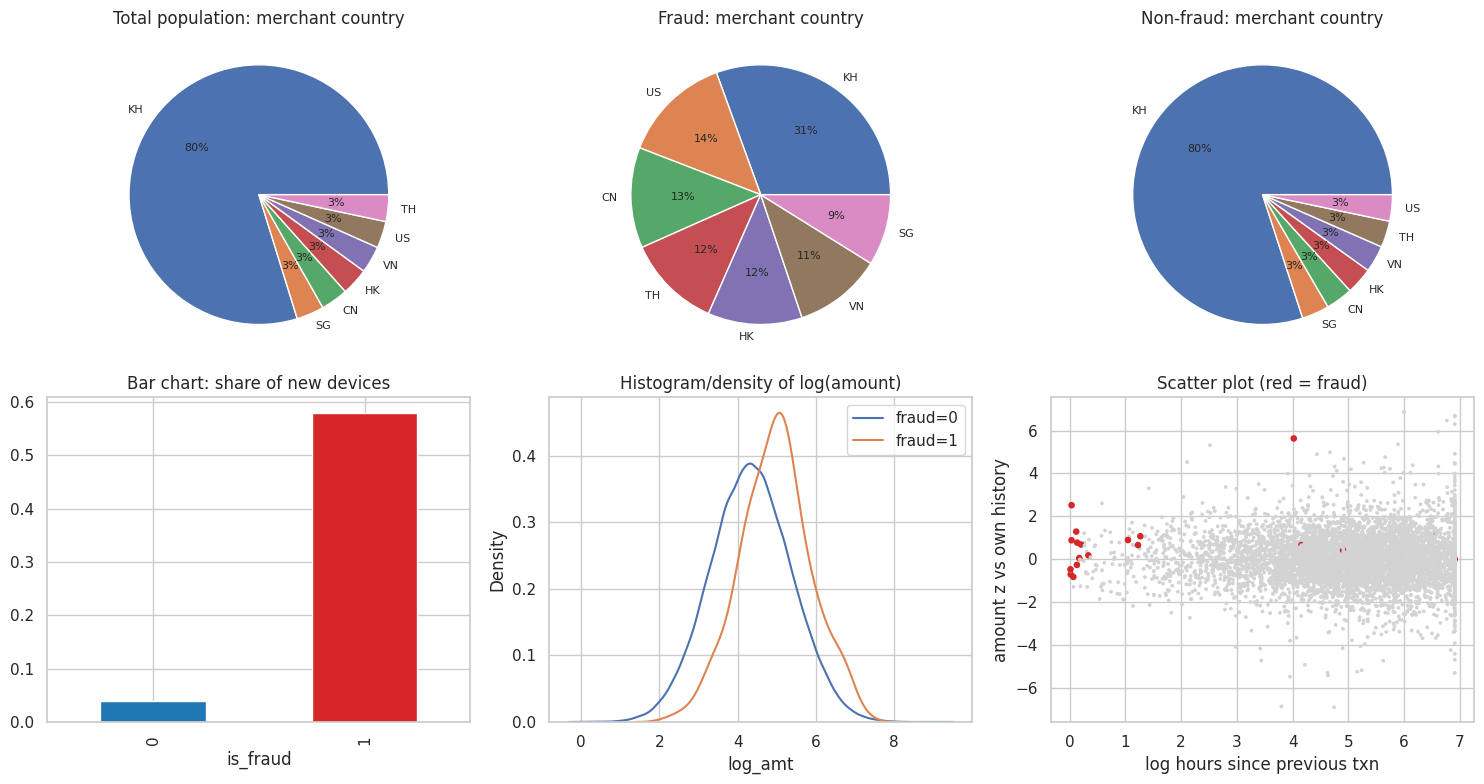

In [8]:
fig, ax = plt.subplots(2, 3, figsize=(15, 8))
for i, (lab, d) in enumerate([("Total population", cards), ("Fraud", cards[cards.is_fraud == 1]), ("Non-fraud", cards[cards.is_fraud == 0])]):
    vc = d.country.value_counts(); ax[0, i].pie(vc.values, labels=vc.index, autopct="%1.0f%%", textprops={"fontsize": 8}); ax[0, i].set_title(f"{lab}: merchant country")
cards.groupby("is_fraud").new_device.mean().plot.bar(ax=ax[1, 0], color=["tab:blue", "tab:red"]); ax[1, 0].set(title="Bar chart: share of new devices", xlabel="is_fraud")
for c, g in cards.groupby("is_fraud"): sns.kdeplot(g.log_amt, ax=ax[1, 1], label=f"fraud={c}", common_norm=False)
ax[1, 1].set(title="Histogram/density of log(amount)"); ax[1, 1].legend()
s = cards.sample(6000, random_state=1); ax[1, 2].scatter(s.log_hrs_since_prev, s.amt_z, c=np.where(s.is_fraud == 1, "tab:red", "lightgrey"), s=np.where(s.is_fraud == 1, 14, 3))
ax[1, 2].set(xlabel="log hours since previous txn", ylabel="amount z vs own history", title="Scatter plot (red = fraud)")
plt.tight_layout(); plt.show()

## 6 · Benford's law
Probability that the leading digit is *d*: **P(d) = log₁₀(1 + 1/d)**. A **screening** tool: strong deviations suggest manipulated (or badly merged / duplicated) data; conformity does *not* prove innocence; needs enough numbers per case. Measures: chi-square goodness-of-fit and Nigrini's MAD.

In [9]:
BEN = np.log10(1 + 1 / np.arange(1, 10)); print("Benford P(d):", dict(zip(range(1, 10), BEN.round(3))))
def first_digit(x):
    x = np.asarray(x, float); x = x[x > 0]; return (x / 10 ** np.floor(np.log10(x))).astype(int)
def benford(x):
    d = first_digit(x); obs = np.bincount(d, minlength=10)[1:]; n = len(d)
    chi2, p = stats.chisquare(obs, BEN * n); return dict(n=n, chi2=chi2, p=p, MAD=np.abs(obs / n - BEN).mean())

genuine = np.exp(rng.normal(8, 2.2, 3000))                               # wide-range 'natural' amounts
invented = rng.integers(100, 9000, 3000) // 100 * 100 + rng.integers(0, 100, 3000)    # a human 'making up' invoice amounts (uniform digits)
capped = np.clip(genuine, 1000, 9990)                                    # amounts squeezed under an approval limit
print(pd.DataFrame({"genuine": benford(genuine), "made-up": benford(invented), "clipped under limit": benford(capped)}).T)

Benford P(d): {1: np.float64(0.301), 2: np.float64(0.176), 3: np.float64(0.125), 4: np.float64(0.097), 5: np.float64(0.079), 6: np.float64(0.067), 7: np.float64(0.058), 8: np.float64(0.051), 9: np.float64(0.046)}
                             n       chi2      p    MAD
genuine             3,000.0000     8.7273 0.3658 0.0046
made-up             3,000.0000 1,244.4792 0.0000 0.0593
clipped under limit 3,000.0000 5,173.2820 0.0000 0.0897


In [10]:
# Benford as a DATA-QUALITY check (chapter: also flags merging problems / duplicates): contaminate card_pos amounts with KHR-denominated values
base_amt = txn.loc[txn.channel == "card_pos", "amount_usd"].values
def contaminate(share):
    a = base_amt.copy(); i = rng.random(len(a)) < share; a[i] = np.round(a[i] * ak.KHR_PER_USD / 100) * 100; return a      # amount kept in KHR by mistake
print(pd.DataFrame({f"{int(sh * 100)}% of rows in KHR (not converted)": benford(contaminate(sh)) for sh in (0, 0.08, 0.4, 0.8)}).T[["n", "MAD"]])
print("the lab's real contamination (8%) is too small to move MAD much - Benford is a coarse screen; the DQ checks of notebook 01 catch it directly.")
by_ch = pd.DataFrame({c: benford(g.amount_usd) for c, g in txn.groupby("channel")}).T[["n", "MAD"]]
print("MAD by channel (Nigrini: <0.006 close, <0.012 acceptable, <0.015 marginal, else non-conformity)"); by_ch

                                              n    MAD
0% of rows in KHR (not converted)  197,218.0000 0.0053
8% of rows in KHR (not converted)  197,218.0000 0.0047
40% of rows in KHR (not converted) 197,218.0000 0.0022
80% of rows in KHR (not converted) 197,218.0000 0.0035
the lab's real contamination (8%) is too small to move MAD much - Benford is a coarse screen; the DQ checks of notebook 01 catch it directly.


MAD by channel (Nigrini: <0.006 close, <0.012 acceptable, <0.015 marginal, else non-conformity)


,n,MAD
card_online,"84,463.0000",0.0026
card_pos,"197,218.0000",0.0053
cash_deposit,"99,763.0000",0.0041
cash_withdrawal,"72,881.0000",0.0027
transfer_in,"133,804.0000",0.0014
transfer_out,"136,012.0000",0.0012
wire_in,"47,865.0000",0.0013
wire_out,"48,939.0000",0.0009


## 7 · Descriptive statistics
Mean, median (robust), standard deviation, percentiles, **skewness** (asymmetry) and **kurtosis** (peakedness/tails; harder to interpret → also look at plots), and the **mode** for categorical variables. Assess them *together*, and per target class.

In [11]:
def describe_full(s):
    return pd.Series({"mean": s.mean(), "median": s.median(), "std": s.std(), "p10": s.quantile(.1), "p25": s.quantile(.25), "p75": s.quantile(.75), "p90": s.quantile(.9),
                      "skew": stats.skew(s), "kurtosis": stats.kurtosis(s)})
print(cards.groupby("is_fraud").amount_usd.apply(describe_full).unstack().round(2))
print("mode of categorical variables ->", {c: cards[c].mode().iloc[0] for c in ["country"]}, "| segment mode:", kyc.segment.mode().iloc[0])

             mean   median      std     p10     p25      p75      p90   skew  \
is_fraud                                                                       
0        130.6600  76.1800 182.8400 20.4700 38.1500 153.5600 290.3700 8.9200   
1        211.9800 147.6300 212.8500 45.9500 78.9700 247.0000 462.5400 2.3600   

          kurtosis  
is_fraud            
0         271.6400  
1           6.6500  
mode of categorical variables -> {'country': 'KH'} | segment mode: retail_salaried


## 8 · Missing values
Reasons: **non-applicable**, **undisclosed**, or **errors** (e.g. merge typos). Three schemes: **Replace (impute)** (mean/median, mode, or regression-based), **Delete**, **Keep** (missing as its own category — it may be informative). Practical rule from the book: *test whether missingness relates to the target (χ²); if yes → keep; if not → delete or impute.*

In [12]:
t21 = pd.DataFrame({"ID": range(1, 11), "Age": [34, 28, 22, 60, 58, 44, 22, 26, 34, 50], "Income": [1800, 1200, 1000, 2200, 2000, np.nan, 1200, 1500, np.nan, 2100],
                    "Marital": [np.nan, "Single", "Single", "Widowed", "Married", np.nan, "Single", "Married", "Single", "Divorced"],
                    "CreditScore": [620, np.nan, np.nan, 700, np.nan, np.nan, np.nan, 350, np.nan, np.nan], "Fraud": ["Yes", "No", "No", "Yes", "No", "No", "No", "No", "Yes", "No"]})
imp = t21.copy()
imp["Income_median"] = imp.Income.fillna(imp.Income.median()); imp["Marital_mode"] = imp.Marital.fillna(imp.Marital.mode()[0])
known = imp.CreditScore.notna() & imp.Income.notna()                       # regression-based imputation of the credit score from age & income
reg = LinearRegression().fit(imp.loc[known, ["Age", "Income"]], imp.loc[known, "CreditScore"])
can = imp.CreditScore.isna() & imp.Income.notna(); imp["Score_regression"] = imp.CreditScore
imp.loc[can, "Score_regression"] = reg.predict(imp.loc[can, ["Age", "Income"]])
imp["Marital_keep"] = imp.Marital.fillna("MISSING")
print("regression imputation from only", int(known.sum()), "known rows gives absurd scores (negative!) -> the book: added value is questionable; needs plenty of data")                          # 'keep' strategy: missing is a category
display(imp[["ID", "Fraud", "Income", "Income_median", "Marital", "Marital_mode", "Marital_keep", "CreditScore", "Score_regression"]])
print("delete strategy keeps", len(t21.dropna(subset=["Income", "Marital"])), "of 10 rows")
# is missingness related to the target?  chi-square on (missing indicator x fraud) - toy data is tiny, so read as illustration only
ct = pd.crosstab(t21.CreditScore.isna(), t21.Fraud); print(ct); print("Fisher exact p =", round(stats.fisher_exact(ct)[1], 3))

regression imputation from only 3 known rows gives absurd scores (negative!) -> the book: added value is questionable; needs plenty of data


,ID,Fraud,Income,Income_median,Marital,Marital_mode,Marital_keep,CreditScore,Score_regression
0,1,Yes,"1,800.0000","1,800.0000",NaN,Single,MISSING,620.0000,620.0000
1,2,No,"1,200.0000","1,200.0000",Single,Single,Single,NaN,-102.6087
2,3,No,"1,000.0000","1,000.0000",Single,Single,Single,NaN,-270.4348
3,4,Yes,"2,200.0000","2,200.0000",Widowed,Widowed,Widowed,700.0000,700.0000
4,5,No,"2,000.0000","2,000.0000",Married,Married,Married,NaN,459.1304
5,6,No,NaN,"1,650.0000",NaN,Single,MISSING,NaN,NaN
6,7,No,"1,200.0000","1,200.0000",Single,Single,Single,NaN,6.9565
7,8,No,"1,500.0000","1,500.0000",Married,Married,Married,350.0000,350.0000
8,9,Yes,NaN,"1,650.0000",Single,Single,Single,NaN,NaN
9,10,No,"2,100.0000","2,100.0000",Divorced,Divorced,Divorced,NaN,743.9130


delete strategy keeps 7 of 10 rows
Fraud        No  Yes
CreditScore         
False         1    2
True          6    1
Fisher exact p = 0.183


In [13]:
# Lab: KYC turnover missingness is random -> impute.  Simulate an INFORMATIVE (MNAR) variant: suspicious customers hide their declared turnover more often
k = feat[["customer_id", "is_launderer", "declared_monthly_turnover_missing"]].copy()
r = np.random.default_rng(1); k["hidden"] = ((k.is_launderer == 1) & (r.random(len(k)) < 0.35)) | (k.declared_monthly_turnover_missing == 1)
for name, col in [("as generated (random)", "declared_monthly_turnover_missing"), ("simulated MNAR", "hidden")]:
    ct = pd.crosstab(k[col].astype(int), k.is_launderer); chi2, p, *_ = stats.chi2_contingency(ct)
    print(f"{name:24s} suspicious rate | missing = {ct.loc[1, 1] / ct.loc[1].sum():.1%}, present = {ct.loc[0, 1] / ct.loc[0].sum():.1%}   chi2 p-value = {p:.2g}  ->",
          "KEEP as own category" if p < 0.05 else "impute or delete")

as generated (random)    suspicious rate | missing = 4.4%, present = 3.5%   chi2 p-value = 0.66  -> impute or delete
simulated MNAR           suspicious rate | missing = 17.8%, present = 2.6%   chi2 p-value = 9.9e-31  -> KEEP as own category


## 9 · Outlier detection and treatment
*Valid* (boss's salary $1M) vs *invalid* (age 300) outliers; *univariate* vs *multivariate*. **Detection:** min/max, histogram, **box plot** (points beyond 1.5×IQR from the box), **z-score** |z| > 3 (assumes normality), **Grubbs test**, **Mahalanobis distance**, regression residuals, clustering. **Treatment:** invalid → treat as missing (+ indicator); valid → truncate / **winsorize** with limits from z-scores or the more robust **M ± 3s, s = IQR / (2 × 0.6745)**, a sigmoid squash, or expert limits. Some models (trees, NN, SVM) are robust; regressions are sensitive.

z-scores: [-1.0, 1.0, -3.0, 0.0, 2.0, 4.0] -> |z|>3 flags: [80]
box-plot fences (log10): 1.88 .. 5.58 -> 44 outliers | |z|>3: 10 outliers


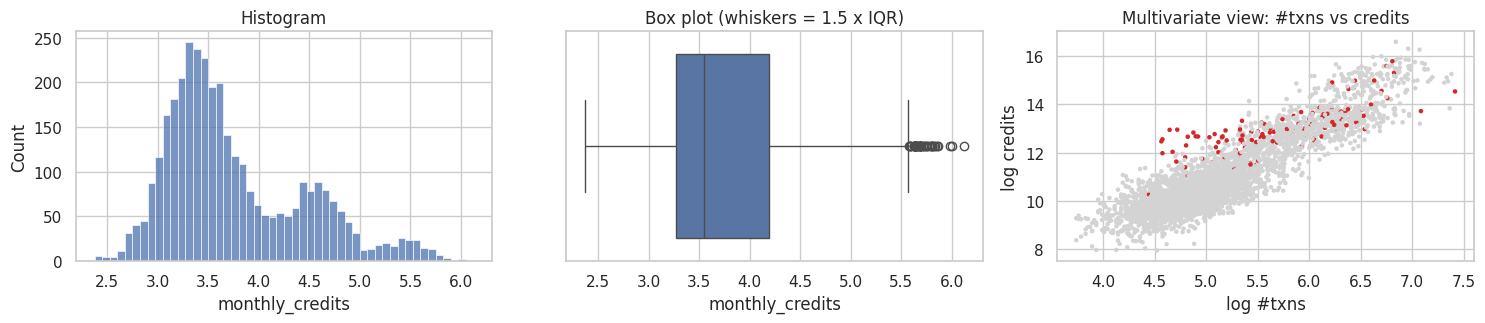

In [14]:
# Book Table 2.2 (mu = 40, sigma = 10)
ages = pd.Series([30, 50, 10, 40, 60, 80]); z = (ages - 40) / 10
assert z.tolist() == [-1, 1, -3, 0, 2, 4]; print("z-scores:", z.tolist(), "-> |z|>3 flags:", ages[z.abs() > 3].tolist())

x = np.log10(feat.monthly_credits.clip(lower=1))                               # lab: monthly credits per customer (log scale)
q1, q3 = x.quantile([.25, .75]); iqr = q3 - q1
fences = (q1 - 1.5 * iqr, q3 + 1.5 * iqr); zz = (x - x.mean()) / x.std()
print(f"box-plot fences (log10): {fences[0]:.2f} .. {fences[1]:.2f} -> {int(((x < fences[0]) | (x > fences[1])).sum())} outliers | |z|>3: {int((zz.abs() > 3).sum())} outliers")
fig, ax = plt.subplots(1, 3, figsize=(15, 3.4)); sns.histplot(x, ax=ax[0], bins=50); sns.boxplot(x=x, ax=ax[1]); ax[0].set_title("Histogram"); ax[1].set_title("Box plot (whiskers = 1.5 x IQR)")
ax[2].scatter(feat.log_n_txn, feat.log_credits, s=5, c=np.where(feat.is_launderer == 1, "tab:red", "lightgrey")); ax[2].set(title="Multivariate view: #txns vs credits", xlabel="log #txns", ylabel="log credits"); plt.tight_layout(); plt.show()

In [15]:
def grubbs(v, alpha=0.05):
    '''Iterative Grubbs test exactly as in the chapter: outlier if G > (N-1)/sqrt(N) * sqrt(t^2 / (N-2+t^2)), t = t_{alpha/(2N), N-2}.'''
    v = np.asarray(v, float).copy(); removed = []
    while len(v) > 3:
        N = len(v); zs = np.abs((v - v.mean()) / v.std(ddof=1)); i = zs.argmax(); G = zs[i]
        t = stats.t.ppf(1 - alpha / (2 * N), N - 2); crit = (N - 1) / np.sqrt(N) * np.sqrt(t ** 2 / (N - 2 + t ** 2))
        if G > crit: removed.append(v[i]); v = np.delete(v, i)
        else: break
    return removed
sample = np.r_[rng.normal(50, 5, 60), [95, 2]]
print("Grubbs on synthetic sample with two planted outliers:", np.round(grubbs(sample), 1))
lg = x.values; rem = grubbs(lg[:2000]); print(f"Grubbs on 2,000 log-credits (heavy-tailed, not normal!): removes {len(rem)} points -> the normality assumption is doubtful")

# Mahalanobis distance: sqrt((x - mean)' S^-1 (x - mean)) ; cutoff from chi-square with 2 dof
Z2 = feat[["log_n_txn", "log_credits"]].values; mu = Z2.mean(0); S = np.cov(Z2.T); d2 = np.einsum("ij,jk,ik->i", Z2 - mu, np.linalg.inv(S), Z2 - mu)
multi = d2 > stats.chi2.ppf(0.999, 2)
print(f"Mahalanobis multivariate outliers (chi2 99.9%): {int(multi.sum())} customers, of which suspicious (oracle): {int(feat.is_launderer[multi].sum())}")
# regression-residual approach
res = feat.log_credits - LinearRegression().fit(feat[["log_n_txn"]], feat.log_credits).predict(feat[["log_n_txn"]]); print("|residual| > 3 sd:", int((res.abs() > 3 * res.std()).sum()))

Grubbs on synthetic sample with two planted outliers: [ 2. 95.]
Grubbs on 2,000 log-credits (heavy-tailed, not normal!): removes 0 points -> the normality assumption is doubtful
Mahalanobis multivariate outliers (chi2 99.9%): 7 customers, of which suspicious (oracle): 4
|residual| > 3 sd: 17


In [16]:
# ---- treatment: capping / truncation / winsorizing --------------------------------------
v = feat.monthly_credits.copy()
M, s = v.median(), (v.quantile(.75) - v.quantile(.25)) / (2 * 0.6745)             # robust limits: M +/- 3s
lo, hi = M - 3 * s, M + 3 * s
cap_iqr = v.clip(lo, hi); cap_z = v.clip(v.mean() - 3 * v.std(), v.mean() + 3 * v.std()); sigmoid = 1 / (1 + np.exp(-((v - M) / s)))
print(pd.DataFrame({"raw": v.describe(), "cap z (mu+-3sd)": cap_z.describe(), "cap robust (M+-3s)": cap_iqr.describe()}).round(0))
print("share of customers capped by the robust rule:", f"{((v < lo) | (v > hi)).mean():.1%}", "(with heavy tails a lot gets capped -> apply on the LOG scale or use expert limits)")

# invalid-but-not-outlying values need a RULE set (the book's 'male & pregnant' example)
rules = {"amount <= 0": (raw.amount <= 0), "KHR amount on cash deposit (never valid)": ((raw.currency == "KHR") & (raw.channel == "cash_deposit")),
         "new_device flag on non-online channel": ((raw.new_device == 1) & (raw.channel != "card_online")),
         "timestamp outside reporting year": ((raw.ts < ak.START) | (raw.ts >= ak.START + pd.Timedelta(days=365)))}
kr = {"duplicate KYC customer_id": kyc_raw.duplicated("customer_id"), "retail_salaried declaring > 50k monthly turnover": ((kyc.segment == "retail_salaried") & (kyc.declared_monthly_turnover > 50_000))}
print(pd.Series({**{k: int(v.sum()) for k, v in rules.items()}, **{k: int(v.sum()) for k, v in kr.items()}}, name="violations").to_frame())

                 raw  cap z (mu+-3sd)  cap robust (M+-3s)
count     3,500.0000       3,500.0000          3,500.0000
mean     27,351.0000      23,040.0000         10,346.0000
std      79,392.0000      52,815.0000         12,424.0000
min         238.0000         238.0000            238.0000
25%       1,849.0000       1,849.0000          1,849.0000
50%       3,564.0000       3,564.0000          3,564.0000
75%      15,566.0000      15,566.0000         15,566.0000
max   1,324,515.0000     265,528.0000         34,069.0000
share of customers capped by the robust rule: 16.5% (with heavy tails a lot gets capped -> apply on the LOG scale or use expert limits)
                                                  violations
amount <= 0                                              513
KHR amount on cash deposit (never valid)                   0
new_device flag on non-online channel                      0
timestamp outside reporting year                           0
duplicate KYC customer_id            

## 10 · Red flags
> *"The fundamental red flag of fraud is the anomaly — something that seems out of place."* Red flags are translated into **expert rules** for a rule engine. **Document the reasoning** behind each flag so investigators know *why* it fired. Book examples (credit-card): a **small payment followed immediately by a large one** (card-testing) and **regular small payments** (avoiding notice).

Warning from the chapter: treating *valid* outliers can **destroy** the very signals unsupervised methods look for. We test that claim below.

In [17]:
c = cards.sort_values(["customer_id", "ts"]).copy(); g = c.groupby("customer_id")
c["prev_amt"] = g.amount_usd.shift(); c["gap_h"] = g.ts.diff().dt.total_seconds() / 3600
c["rf_small_then_large"] = ((c.prev_amt <= 15) & (c.amount_usd >= 8 * c.prev_amt) & (c.gap_h <= 1)).astype(int)         # card-testing pattern
c["rf_burst"] = (c.n_prev_1h >= 3).astype(int)                                                                              # 'high volume over short periods'
catalog = pd.DataFrame([("rf_small_then_large", "prev txn <= $15 then >= 8x within 1h", "fraudster tests that the card is alive, then cashes out", "hold + call customer"),
                        ("rf_burst", ">= 3 card-online txns in previous hour", "high volume over a short period", "step-up authentication"),
                        ("rf_near_ctr (customer)", ">= 3 cash deposits in 75-100% of the reporting threshold", "regular smaller payments to avoid notice (structuring)", "open AML alert")],
                       columns=["red flag", "rule", "documented rationale", "action"]); display(catalog)
base = c.is_fraud.mean()
print(pd.DataFrame({f: dict(hit_rate=c[f].mean(), precision=c.is_fraud[c[f] == 1].mean(), lift=c.is_fraud[c[f] == 1].mean() / base) for f in ["rf_small_then_large", "rf_burst"]}).T)

,red flag,rule,documented rationale,action
0,rf_small_then_large,prev txn <= $15 then >= 8x within 1h,"fraudster tests that the card is alive, then c...",hold + call customer
1,rf_burst,>= 3 card-online txns in previous hour,high volume over a short period,step-up authentication
2,rf_near_ctr (customer),>= 3 cash deposits in 75-100% of the reporting...,regular smaller payments to avoid notice (stru...,open AML alert


                     hit_rate  precision     lift
rf_small_then_large    0.0001     0.0909  20.0482
rf_burst               0.0015     1.0000 220.5300


In [18]:
# Does capping valid outliers hurt unsupervised anomaly detection?  robust-z sum score, raw vs winsorised inputs, graded with the oracle
cols = ["log_max_cash_agg_5d", "log_turnover_ratio", "log_amt_wire_in", "hr_share", "near_ctr_cnt", "flowthrough_max"]
def score(df):
    return sum(((df[c] - df[c].median()) / max(stats.median_abs_deviation(df[c], scale="normal"), 0.1 * df[c].std())).clip(0, 50) for c in cols)
raw_s = score(feat); w = feat.copy()
for c_ in cols: w[c_] = w[c_].clip(w[c_].quantile(.01), w[c_].quantile(.95))                     # winsorise at the 95th percentile
print(f"AUC of anomaly score: raw inputs {roc_auc_score(feat.is_launderer, raw_s):.3f}  |  after winsorising valid outliers {roc_auc_score(feat.is_launderer, score(w)):.3f}")

AUC of anomaly score: raw inputs 0.893  |  after winsorising valid outliers 0.848


## 11 · Standardizing data
Bring variables to a similar scale (needed for regressions, distance-based methods, SOM, SVM; **not** for trees). Three procedures:
* **Min/max**: X_new = (X − min)/(max − min) · (newmax − newmin) + newmin
* **z-score**: (X − μ)/σ
* **Decimal scaling**: X / 10ⁿ, n = digits of the max absolute value

In [19]:
def minmax(x, lo=0, hi=1): x = np.asarray(x, float); return (x - x.min()) / (x.max() - x.min()) * (hi - lo) + lo
def zscore(x): x = np.asarray(x, float); return (x - x.mean()) / x.std()
def decimal(x): x = np.asarray(x, float); n = len(str(int(np.abs(x).max()))); return x / 10 ** n
inc = np.array([1000, 1200, 1300, 2000, 1800, 1400, 250_000.0])
print(pd.DataFrame({"raw": inc, "min-max": minmax(inc), "z-score": zscore(inc), "decimal": decimal(inc)}).round(4))

# effect on a coefficient: gender-like 0/1 vs income-like huge scale (chapter motivation)
X = feat[["near_ctr_cnt", "credits"]].copy(); yy = feat.is_launderer
b_raw = LogisticRegression(max_iter=5000, C=1e6).fit(X, yy).coef_[0]; b_std = LogisticRegression(max_iter=5000, C=1e6).fit(StandardScaler().fit_transform(X), yy).coef_[0]
print("logistic coefficients  raw:", b_raw.round(6), "| standardised:", b_std.round(3), "-> raw 'credits' coefficient is tiny only because of its units")
Xt = feat[["credits", "near_ctr_cnt"]]
print("tree AUC unchanged by scaling:", round(roc_auc_score(yy, DecisionTreeClassifier(max_depth=3, random_state=0).fit(Xt, yy).predict_proba(Xt)[:, 1]), 4), "=",
      round(roc_auc_score(yy, DecisionTreeClassifier(max_depth=3, random_state=0).fit(StandardScaler().fit_transform(Xt), yy).predict_proba(StandardScaler().fit_transform(Xt))[:, 1]), 4))

           raw  min-max  z-score  decimal
0   1,000.0000   0.0000  -0.4134   0.0010
1   1,200.0000   0.0008  -0.4111   0.0012
2   1,300.0000   0.0012  -0.4100   0.0013
3   2,000.0000   0.0040  -0.4019   0.0020
4   1,800.0000   0.0032  -0.4042   0.0018
5   1,400.0000   0.0016  -0.4088   0.0014
6 250,000.0000   1.0000   2.4495   0.2500
logistic coefficients  raw: [ 0.244015 -0.      ] | standardised: [ 1.007 -0.101] -> raw 'credits' coefficient is tiny only because of its units
tree AUC unchanged by scaling: 0.8934 = 0.8934


## 12 · Categorization (coarse classification, binning, grouping)
*Why:* (a) reduce the number of categories of a categorical variable (50 countries → 49 dummies), (b) model **non-monotonic** / non-linear effects with linear models, (c) robustness. Methods: **equal interval**, **equal frequency**, **odds-based grouping (pivot table)**, and **χ² analysis** (compare observed with independence frequencies; larger χ² = better grouping).

In [20]:
inc = pd.Series([1000, 1200, 1300, 2000, 1800, 1400])
print("equal interval :", pd.cut(inc, 2).astype(str).tolist()); print("equal frequency:", pd.qcut(inc, 2).astype(str).tolist())

# Book Table 2.4: pivot table + odds -> group categories with similar odds
piv = pd.DataFrame({"Clothes": [1000, 500], "Books": [2000, 100], "Music": [3000, 200], "Electro": [100, 80], "Games": [5000, 800]}, index=["Good", "Bad"])
piv.loc["Odds"] = piv.loc["Good"] / piv.loc["Bad"]; display(piv)

# Book Tables 2.5-2.7: chi-square to compare two candidate groupings
t25 = pd.DataFrame({"Clothes": [6000, 300], "Books": [1600, 400], "Music": [350, 140], "Electro": [950, 100], "Games": [90, 50], "Movies": [10, 10]}, index=["No-fraud", "Fraud"])
def chi2_grouping(tab, groups):
    g = pd.DataFrame({name: tab[cols].sum(axis=1) for name, cols in groups.items()})
    return stats.chi2_contingency(g, correction=False)[0]
opt1 = {"Clothes": ["Clothes"], "Books&Music": ["Books", "Music"], "Others": ["Electro", "Games", "Movies"]}
opt2 = {"Clothes": ["Clothes"], "Electro": ["Electro"], "Others": ["Books", "Music", "Games", "Movies"]}
c1, c2 = chi2_grouping(t25, opt1), chi2_grouping(t25, opt2); print(f"chi2 option 1 = {c1:.0f} | option 2 = {c2:.0f}  (book: 583 and 662, truncated) -> option 2 is the better grouping")
assert abs(c1 - 583) < 1.5 and abs(c2 - 662) < 1.5           # the book truncates 583.9 and 662.9

equal interval : ['(999.0, 1500.0]', '(999.0, 1500.0]', '(999.0, 1500.0]', '(1500.0, 2000.0]', '(1500.0, 2000.0]', '(999.0, 1500.0]']
equal frequency: ['(999.999, 1350.0]', '(999.999, 1350.0]', '(999.999, 1350.0]', '(1350.0, 2000.0]', '(1350.0, 2000.0]', '(1350.0, 2000.0]']


,Clothes,Books,Music,Electro,Games
Good,"1,000.0000","2,000.0000","3,000.0000",100.0000,"5,000.0000"
Bad,500.0000,100.0000,200.0000,80.0000,800.0000
Odds,2.0000,20.0000,15.0000,1.2500,6.2500


chi2 option 1 = 584 | option 2 = 663  (book: 583 and 662, truncated) -> option 2 is the better grouping


In [21]:
# Non-monotonic relation and a LINEAR model: fraud risk vs hour of day (card fraud)
cf = cards.assign(hour_i=cards.hour); trn, tst = cf[cf.day < 255], cf[cf.day >= 255]
risk = cf.groupby("hour_i").is_fraud.mean(); print("fraud rate by hour is non-monotonic:", risk.round(4).to_dict() if False else f"min {risk.min():.4f} at h={risk.idxmin()}, max {risk.max():.4f} at h={risk.idxmax()}")
bins = [-1, 5, 11, 17, 21, 23]; lab = ["night", "morning", "afternoon", "evening", "late"]
def dm(df, how):
    return df[["hour_i"]] if how == "raw" else pd.get_dummies(pd.cut(df.hour_i, bins, labels=lab)).astype(float)
for how in ("raw", "binned"):
    m = LogisticRegression(max_iter=2000).fit(dm(trn, how), trn.is_fraud); print(f"logistic on hour ({how:6s}) test AUC = {roc_auc_score(tst.is_fraud, m.predict_proba(dm(tst, how))[:, 1]):.3f}")

fraud rate by hour is non-monotonic: min 0.0009 at h=21, max 0.0161 at h=0
logistic on hour (raw   ) test AUC = 0.511
logistic on hour (binned) test AUC = 0.669


## 13 · Weights of evidence (WoE) coding
Replaces each category by a number **monotonically related to the target**: **WoE = ln(Dist No-fraud / Dist Fraud)** (positive → relatively more non-fraud). A model on WoE-coded variables needs **one parameter per characteristic** instead of one per category: `Y = β₀ + β₁·WoE_age + β₂·WoE_product`. Cost: interpretability of the raw coefficients.

In [22]:
t28 = pd.DataFrame({"Age": ["Missing", "18-22", "23-26", "27-29", "30-35", "35-44", "44+"], "nofraud": [42, 152, 246, 405, 475, 339, 147], "fraud": [8, 48, 54, 45, 25, 11, 3]}).set_index("Age")
def woe_table(tab, good="nofraud", bad="fraud"):
    t = tab.copy(); t["dist_good"] = t[good] / t[good].sum(); t["dist_bad"] = t[bad] / t[bad].sum()
    t["WoE"] = np.log(t.dist_good / t.dist_bad); t["IV"] = (t.dist_good - t.dist_bad) * t.WoE; return t
w = woe_table(t28); display(w.round(4)); print("Information value =", round(w.IV.sum(), 4)); assert abs(w.IV.sum() - 0.6502) < 1e-3     # book Table 2.10

,nofraud,fraud,dist_good,dist_bad,WoE,IV
Age,,,,,,
Missing,42,8,0.0233,0.0412,-0.5728,0.0103
18-22,152,48,0.0842,0.2474,-1.0783,0.1760
23-26,246,54,0.1362,0.2784,-0.7147,0.1016
27-29,405,45,0.2243,0.2320,-0.0338,0.0003
30-35,475,25,0.2630,0.1289,0.7134,0.0957
35-44,339,11,0.1877,0.0567,1.1971,0.1568
44+,147,3,0.0814,0.0155,1.6608,0.1095


Information value = 0.6502


In [23]:
# WoE-coded logistic model on the lab card-fraud data: fit bins/WoE on TRAIN only
def make_bins(s, q=8):
    edges = np.unique(np.quantile(s, np.linspace(0, 1, q + 1))); edges[0], edges[-1] = -np.inf, np.inf; return edges
num = ["log_amt", "amt_z", "log_hrs_since_prev", "hour"]; cat = ["foreign", "new_device", "night", "n_prev_1h_c", "n_prev_24h_c"]
E = {c_: make_bins(trn[c_], 8) for c_ in num}
def binned(df, c_): return pd.cut(df[c_], E[c_], labels=False, duplicates="drop") if c_ in E else df[c_].astype(int)
woe_maps = {}
for c_ in num + cat:
    tab = pd.crosstab(binned(trn, c_), trn.is_fraud); tab.columns = ["nofraud", "fraud"]; tab = tab + 0.5
    woe_maps[c_] = woe_table(tab).WoE
def to_woe(df): return pd.DataFrame({c_: binned(df, c_).map(woe_maps[c_]).fillna(0) for c_ in woe_maps})
Xw_tr, Xw_te = to_woe(trn), to_woe(tst)
m_w = LogisticRegression(max_iter=2000).fit(Xw_tr, trn.is_fraud); m_r = LogisticRegression(max_iter=3000).fit(StandardScaler().fit(trn[num + cat]).transform(trn[num + cat]), trn.is_fraud)
print(f"test AUC  WoE-coded ({Xw_tr.shape[1]} params): {roc_auc_score(tst.is_fraud, m_w.predict_proba(Xw_te)[:, 1]):.3f} | raw standardised: "
      f"{roc_auc_score(tst.is_fraud, m_r.predict_proba(StandardScaler().fit(trn[num + cat]).transform(tst[num + cat]))[:, 1]):.3f}")
print("coefficients on WoE (all should be NEGATIVE: higher WoE = more non-fraud-like):"); print(pd.Series(m_w.coef_[0], index=Xw_tr.columns).round(3).to_dict())

test AUC  WoE-coded (9 params): 0.948 | raw standardised: 0.946
coefficients on WoE (all should be NEGATIVE: higher WoE = more non-fraud-like):
{'log_amt': -0.745, 'amt_z': -0.333, 'log_hrs_since_prev': -0.415, 'hour': -0.645, 'foreign': -0.988, 'new_device': -1.045, 'night': -0.601, 'n_prev_1h_c': -0.804, 'n_prev_24h_c': -0.21}


## 14 · Variable selection: filters
Fraud models typically use 10–15 variables. **Filters** rank variables by *univariate* association with the target (Table 2.9):

| | continuous target | categorical target (fraud) |
|---|---|---|
| continuous variable | Pearson correlation | **Fisher score** = \|X̄_G − X̄_B\| / √(s²_G + s²_B) |
| categorical variable | Fisher score / ANOVA | **Information value**, **Cramér's V**, gain/entropy |

Rules of thumb: IV < 0.02 unpredictive, 0.02–0.1 weak, 0.1–0.3 medium, > 0.3 strong; Cramér's V cut-off 0.1. Drawback: univariate → ignores correlation between variables → follow up with a multivariate check. Other criteria: regulation/privacy and operational feasibility (real-time computation).

In [24]:
# Book Table 2.11 -> chi2 = 10.41, Cramer's V = 0.10
ct = np.array([[500, 100], [300, 100]]); chi2, *_ = stats.chi2_contingency(ct, correction=False); V = np.sqrt(chi2 / ct.sum())
print(f"chi2 = {chi2:.2f}, Cramer's V = {V:.2f}"); assert abs(chi2 - 10.41) < 0.01 and round(V, 2) == 0.10

def entropy(p): p = np.asarray(p, float); p = p[p > 0]; return -(p * np.log2(p)).sum()
def info_gain(x, y): 
    H = entropy(np.bincount(y) / len(y)); return H - sum((x == v).mean() * entropy(np.bincount(y[x == v], minlength=2) / max((x == v).sum(), 1)) for v in np.unique(x))
def iv_of(x, y, q=8):
    d = pd.DataFrame({"x": pd.qcut(x, q, duplicates="drop") if x.nunique() > 6 else x, "y": y}); t = d.groupby("x", observed=True).y.agg(fraud="sum", n="count"); t["nofraud"] = t.n - t.fraud
    return woe_table(t[["nofraud", "fraud"]] + 0.5).IV.sum()
def cramers(x, y): 
    tab = pd.crosstab(pd.qcut(x, 8, duplicates="drop") if x.nunique() > 6 else x, y); chi2 = stats.chi2_contingency(tab, correction=False)[0]; return np.sqrt(chi2 / (tab.values.sum() * (min(tab.shape) - 1)))
yv = cards.is_fraud.values; rows = {}
for c_ in num + cat:
    xs = cards[c_]; g, b = xs[yv == 0], xs[yv == 1]
    xb = pd.qcut(xs, 8, labels=False, duplicates="drop") if xs.nunique() > 6 else xs
    rows[c_] = dict(Pearson=xs.corr(pd.Series(yv, index=xs.index)), Fisher=abs(g.mean() - b.mean()) / np.sqrt(g.var() + b.var()), IV=iv_of(xs, yv), CramersV=cramers(xs, yv), InfoGain=info_gain(xb.values, yv))
filt = pd.DataFrame(rows).T; filt["rank (mean of ranks)"] = filt[["Fisher", "IV", "CramersV", "InfoGain"]].rank(ascending=False).mean(axis=1); filt.sort_values("rank (mean of ranks)")

chi2 = 10.42, Cramer's V = 0.10


,Pearson,Fisher,IV,CramersV,InfoGain,rank (mean of ranks)
n_prev_1h_c,0.6120,0.9000,4.8860,0.6608,0.0182,1.7500
n_prev_24h_c,0.3154,1.0139,3.9425,0.5251,0.0149,2.2500
new_device,0.1815,1.0173,1.8991,0.1815,0.0078,2.7500
log_hrs_since_prev,-0.1482,1.0812,1.8869,0.1236,0.0066,3.2500
foreign,0.0827,0.8100,1.0895,0.0827,0.0037,5.0000
night,0.0491,0.4485,0.3858,0.0491,0.0014,6.5000
log_amt,0.0407,0.4566,0.4410,0.0419,0.0013,6.7500
hour,-0.0160,0.1430,0.3376,0.0426,0.0011,8.0000
amt_z,0.0284,0.2985,0.1841,0.0294,0.0006,8.7500


In [25]:
# univariate filters ignore redundancy -> check multicollinearity of the survivors (variance inflation factors)
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
keep = filt[(filt.IV > 0.1)].index.tolist(); Xk = StandardScaler().fit_transform(cards[keep])
print("kept by IV > 0.1:", keep); print(pd.Series([vif(Xk, i) for i in range(Xk.shape[1])], index=keep, name="VIF (> 5-10 = redundant)").round(2).to_string())
print("correlated pairs (|r| > 0.6):", [(a, b, round(cards[a].corr(cards[b]), 2)) for i, a in enumerate(keep) for b in keep[i + 1:] if abs(cards[a].corr(cards[b])) > .6])

kept by IV > 0.1: ['log_amt', 'amt_z', 'log_hrs_since_prev', 'hour', 'foreign', 'new_device', 'night', 'n_prev_1h_c', 'n_prev_24h_c']


log_amt              2.2800
amt_z                2.2400
log_hrs_since_prev   1.8000
hour                 1.1500
foreign              1.0000
new_device           1.0100
night                1.1500
n_prev_1h_c          1.3200
n_prev_24h_c         2.1300
correlated pairs (|r| > 0.6): [('log_amt', 'amt_z', np.float64(0.74)), ('log_hrs_since_prev', 'n_prev_24h_c', np.float64(-0.65))]


## 15 · Principal components analysis (PCA)
Forms new variables (**PCs**) that are **linear combinations** of the originals, **uncorrelated**, ordered by variance explained. Steps: eigen-decompose the covariance matrix Σ → eigenvectors *e_j* (weights) and eigenvalues λ_j (variance explained by PC_j); **PC scores** = weights × mean-corrected data. Total variance is preserved (Σλ = Σ variances). Benefit: removes **multicollinearity** → **stable** parameter estimates; price: **reduced interpretability**.

In [26]:
pc_cols = ["log_credits", "log_debits", "log_n_txn", "log_mean_amt", "log_amt_cash_deposit", "log_max_cash_agg_5d"]
Xc = feat[pc_cols].values; Xm = Xc - Xc.mean(0)
Sigma = np.cov(Xm.T); lam, E_ = np.linalg.eigh(Sigma); order = lam.argsort()[::-1]; lam, E_ = lam[order], E_[:, order]
scores = Xm @ E_                                                                     # PC scores by hand
print("eigenvalues:", lam.round(3), "| sum =", lam.sum().round(3), "= total variance", np.trace(Sigma).round(3))
print("PC covariance is diagonal (uncorrelated):", np.allclose(np.cov(scores.T) - np.diag(lam), 0, atol=1e-8))
sk = PCA().fit(Xc); print("matches sklearn (up to sign):", np.allclose(np.abs(sk.transform(Xc)), np.abs(scores)))
print("variance explained:", (lam / lam.sum()).round(3), "cumulative:", (lam / lam.sum()).cumsum().round(3))
print(pd.DataFrame(E_[:, :2], index=pc_cols, columns=["e1 (PC1 weights)", "e2 (PC2 weights)"]).round(3))

eigenvalues: [1.0921e+01 1.2960e+00 2.0200e-01 8.9000e-02 6.3000e-02 1.0000e-03] | sum = 12.572 = total variance 12.572
PC covariance is diagonal (uncorrelated): True
matches sklearn (up to sign): True
variance explained: [0.869 0.103 0.016 0.007 0.005 0.   ] cumulative: [0.869 0.972 0.988 0.995 1.    1.   ]
                      e1 (PC1 weights)  e2 (PC2 weights)
log_credits                    -0.4470           -0.4230
log_debits                     -0.3880           -0.5160
log_n_txn                      -0.1780           -0.1540
log_mean_amt                   -0.2390           -0.3080
log_amt_cash_deposit           -0.6080            0.4810
log_max_cash_agg_5d            -0.4380            0.4530


In [27]:
# Model STABILITY: bootstrap the logistic coefficients with correlated originals vs with uncorrelated PCs
B, yy = 150, feat.is_launderer.values; Xs = StandardScaler().fit_transform(Xc); Pc = PCA().fit_transform(Xs)
def boot_coefs(X):
    out = []; r = np.random.default_rng(0)
    for _ in range(B): i = r.integers(0, len(X), len(X)); out.append(LogisticRegression(max_iter=2000).fit(X[i], yy[i]).coef_[0])
    return np.array(out)
cs_o, cs_p = boot_coefs(Xs), boot_coefs(Pc)
print(pd.DataFrame({"coef sd across bootstraps (original, correlated)": cs_o.std(0), "coef sd (principal components)": cs_p.std(0)}, index=[f"var/PC {i+1}" for i in range(len(pc_cols))]).round(3))
print("correlation between log_credits and log_debits:", round(feat.log_credits.corr(feat.log_debits), 3), "-> large coefficient variance = unstable model")

          coef sd across bootstraps (original, correlated)  \
var/PC 1                                            0.2400   
var/PC 2                                            0.2500   
var/PC 3                                            0.1690   
var/PC 4                                            0.1710   
var/PC 5                                            0.2920   
var/PC 6                                            0.3720   

          coef sd (principal components)  
var/PC 1                          0.0660  
var/PC 2                          0.2360  
var/PC 3                          0.1770  
var/PC 4                          0.3710  
var/PC 5                          0.3990  
var/PC 6                          0.1470  
correlation between log_credits and log_debits: 0.957 -> large coefficient variance = unstable model


## 16 · RIDITs
An alternative to WoE that needs **no target** (usable **unsupervised**): scores for **ordinal** categories. Order the categories from *most* to *least* fraud-suspicious (i = 1…k), with p̂_j the share of the population in category j:

**B_i = Σ_{j<i} p̂_j − Σ_{j>i} p̂_j ∈ [−1, 1]**  — an adjusted percentile: **the rarer/more suspicious the response, the more negative the score**.

In [28]:
def ridit(series, order):
    '''order = categories from MOST suspicious to LEAST suspicious.'''
    p = series.value_counts(normalize=True).reindex(order).fillna(0).values
    b = [p[:i].sum() - p[i + 1:].sum() for i in range(len(order))]
    return series.map(dict(zip(order, b))).astype(float)
# Book example: 10% 'yes' (suspicious) vs 50% 'yes'
for share in (0.10, 0.50):
    s = pd.Series(["yes"] * int(share * 100) + ["no"] * int((1 - share) * 100)); r_ = ridit(s, ["yes", "no"]).groupby(s).first(); print(f"{share:.0%} yes -> RIDIT(yes) = {r_['yes']:+.1f}, RIDIT(no) = {r_['no']:+.1f}")
assert ridit(pd.Series(["yes"] * 10 + ["no"] * 90), ["yes", "no"]).min() == -0.9

10% yes -> RIDIT(yes) = -0.9, RIDIT(no) = +0.1
50% yes -> RIDIT(yes) = -0.5, RIDIT(no) = +0.5


In [29]:
# Lab: ordinal fraud indicators (4 levels each, level 1 = most suspicious)
lv = ["1-very high", "2-high", "3-moderate", "4-normal"]
def ordinal(s, cuts): return pd.cut(s, [-np.inf] + cuts + [np.inf], labels=lv[::-1]).astype(str).pipe(lambda z: pd.Categorical(z, lv))
ind = pd.DataFrame({"turnover_vs_declared": ordinal(feat.turnover_ratio, [1.5, 3, 6]), "cash_burst_5d": ordinal(feat.max_cash_agg_5d, [5_000, 10_000, 30_000]),
                    "near_threshold_deposits": ordinal(feat.near_ctr_cnt, [0.5, 2.5, 6]), "flow_through": ordinal(feat.flowthrough_max, [0.3, 0.7, 0.9]),
                    "high_risk_country_share": ordinal(feat.hr_share, [0.02, 0.05, 0.1])})
F = pd.DataFrame({c_: ridit(ind[c_].astype(str), lv) for c_ in ind}); print(ind.turnover_vs_declared.value_counts(normalize=True).reindex(lv).round(3).to_dict())
pd.DataFrame({lvl: F.loc[ind.turnover_vs_declared.astype(str) == lvl, "turnover_vs_declared"].iloc[0] for lvl in lv}, index=["RIDIT score"]).round(3)

{'1-very high': 0.005, '2-high': 0.011, '3-moderate': 0.154, '4-normal': 0.831}


,1-very high,2-high,3-moderate,4-normal
RIDIT score,-0.9950,-0.9790,-0.8150,0.1690


## 17 · PRIDIT analysis
Combine RIDITs across indicators into one **overall suspicion score**. Simple aggregate S = F·W with W = (1,…,1)′ treats all indicators equally. PRIDIT chooses the weights as the **first principal component of F′F**: an indicator gets a higher weight when its RIDIT scores are *consistent* with the overall score. Indicators with weights ≈ 0 can be dropped (**variable selection**) or the whole set replaced by the score.

In [30]:
Fm = F.values; w_eig, w_vec = np.linalg.eigh(Fm.T @ Fm); w1 = w_vec[:, w_eig.argmax()]; w1 = w1 if w1.sum() > 0 else -w1     # first principal component of F'F (sign: positive weights)
S_pridit, S_equal = Fm @ w1, Fm @ np.ones(Fm.shape[1])
print(pd.Series(w1, index=F.columns, name="PRIDIT weight (unit norm)").round(3).to_string())
suspicion = lambda s: -s                                                                     # lower RIDIT total = more suspicious
print(f"AUC vs oracle  equal weights: {roc_auc_score(feat.is_launderer, suspicion(S_equal)):.3f} | PRIDIT weights: {roc_auc_score(feat.is_launderer, suspicion(S_pridit)):.3f}   (no label was used to build either score!)")
top = feat.assign(pridit=S_pridit).nsmallest(100, "pridit"); print("top-100 most suspicious by PRIDIT contain", int(top.is_launderer.sum()), "true suspicious customers (base rate would give ~", round(100 * feat.is_launderer.mean(), 1), ")")

turnover_vs_declared      0.0830
cash_burst_5d             0.5840
near_threshold_deposits   0.4110
flow_through              0.5450
high_risk_country_share   0.4320
AUC vs oracle  equal weights: 0.858 | PRIDIT weights: 0.830   (no label was used to build either score!)
top-100 most suspicious by PRIDIT contain 20 true suspicious customers (base rate would give ~ 3.5 )


## 18 · Segmentation
Segment **before modelling** when: (a) *strategy* differs by segment, (b) *operations* differ (new customers have no history → separate model), (c) strong **interactions** exist. Segments come from **experts** or **statistics** (decision trees, k-means, SOM). Caveat: *k* segments = *k* models to build, run, monitor and maintain → cost.

In [31]:
Xseg = ["log_turnover_ratio", "log_max_cash_agg_5d", "near_ctr_cnt", "flowthrough_max", "hr_share", "log_n_counterparties", "cash_share_credits", "log_n_txn"]
tr_i, te_i = train_test_split(np.arange(len(feat)), test_size=0.3, stratify=feat.is_launderer, random_state=0)
tr_f, te_f = feat.iloc[tr_i], feat.iloc[te_i]
sc = StandardScaler().fit(tr_f[Xseg]); glob = LogisticRegression(max_iter=3000).fit(sc.transform(tr_f[Xseg]), tr_f.is_launderer)
p_glob = glob.predict_proba(sc.transform(te_f[Xseg]))[:, 1]

def per_segment(train, test, seg_col):
    p = pd.Series(0.0, index=test.index)
    for s, g in train.groupby(seg_col):
        te_s = test[test[seg_col] == s]
        if len(te_s) == 0: continue
        if g.is_launderer.sum() < 5: p[te_s.index] = glob.predict_proba(sc.transform(te_s[Xseg]))[:, 1]; continue       # too few positives: fall back to global
        sc_s = StandardScaler().fit(g[Xseg]); p[te_s.index] = LogisticRegression(max_iter=3000, C=0.5).fit(sc_s.transform(g[Xseg]), g.is_launderer).predict_proba(sc_s.transform(te_s[Xseg]))[:, 1]
    return p
# statistical segmentation: a shallow decision tree, k-means
tree = DecisionTreeClassifier(max_depth=2, min_samples_leaf=100, random_state=0).fit(tr_f[Xseg], tr_f.is_launderer)
tr_f = tr_f.assign(seg_tree=tree.apply(tr_f[Xseg])); te_f = te_f.assign(seg_tree=tree.apply(te_f[Xseg]))
from sklearn.cluster import KMeans
km = KMeans(4, n_init=10, random_state=0).fit(sc.transform(tr_f[Xseg])); tr_f["seg_km"] = km.labels_; te_f["seg_km"] = km.predict(sc.transform(te_f[Xseg]))
segcols = {"one global model": None, "expert segments (declared)": "segment", "tree segments": "seg_tree", "k-means segments": "seg_km"}
res = {k: (p_glob if c_ is None else per_segment(tr_f, te_f, c_).values) for k, c_ in segcols.items()}
out = pd.DataFrame({k: dict(models_to_maintain=1 if segcols[k] is None else tr_f[segcols[k]].nunique(), test_AUC=roc_auc_score(te_f.is_launderer, v)) for k, v in res.items()}).T
out

,models_to_maintain,test_AUC
one global model,1.0000,0.9622
expert segments (declared),5.0000,0.9550
tree segments,3.0000,0.9514
k-means segments,4.0000,0.9733


Segmentation may or may not help discrimination, but it **always** multiplies the number of models to validate and monitor — the trade-off the chapter warns about. Segments are often more valuable for **strategy** (different thresholds/actions per segment, as in the AML threshold-tuning chapters) than for raw accuracy.

### Chapter 2 checklist
- [ ] Data sources listed; merged with **key checks** · [ ] sampling window covers a business cycle; stratified on the target · [ ] data element types declared · [ ] Benford run as screening **and** data-quality tool · [ ] missing values tested against the target before deciding · [ ] outliers classified valid/invalid; **valid outliers not blindly capped** before unsupervised modelling · [ ] red flags documented with rationale · [ ] scaling/binning/WoE fitted **on training data only** · [ ] filters + multicollinearity check · [ ] PCA / (P)RIDIT where interpretability is not critical or no labels exist · [ ] segmentation justified vs. its maintenance cost

**Next → `03b_ch3_descriptive_analytics_concepts`**